In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/dataco-smart-supply-chain-for-big-data-analysis")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis


In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv', 
                 encoding='latin-1')

# First look
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (180519, 53)

Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Sta

In [4]:
# Focus on the columns we actually need
cols_needed = [
    'order date (DateOrders)',
    'Product Name',
    'Category Name',
    'Department Name',
    'Order Item Quantity',
    'Order Item Product Price',
    'Order Status',
    'Delivery Status',
    'Late_delivery_risk',
    'Days for shipping (real)',
    'Days for shipment (scheduled)'
]

df_clean = df[cols_needed].copy()

# Parse date
df_clean['order_date'] = pd.to_datetime(df_clean['order date (DateOrders)'])

# Quick summary
print("Date range:", df_clean['order_date'].min(), "to", df_clean['order_date'].max())
print("\nOrder Status values:")
print(df_clean['Order Status'].value_counts())
print("\nDelivery Status values:")
print(df_clean['Delivery Status'].value_counts())
print("\nTop 10 Product Names:")
print(df_clean['Product Name'].value_counts().head(10))
print("\nCategory Names:")
print(df_clean['Category Name'].value_counts())
print("\nNull counts:")
print(df_clean.isnull().sum())

Date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00

Order Status values:
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Delivery Status values:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Top 10 Product Names:
Product Name
Perfect Fitness Perfect Rip Deck                 24515
Nike Men's CJ Elite 2 TD Football Cleat          22246
Nike Men's Dri-FIT Victory Golf Polo             21035
O'Brien Men's Neoprene Life Vest                 19298
Field & Stream Sportsman 16 Gun Fire Safe        17325
Pelican Sunstream 100 Kayak                      15500
Diamondback Women's Serene Classic Comfort Bi    13729
Nike Men's Free 5.0+ Running Shoe                12169
Under Ar

In [5]:
# ============================================
# STOCKOUT RISK DETECTION MODEL
# ============================================

# Step 1 — Filter only completed/valid orders
valid_statuses = ['COMPLETE', 'CLOSED', 'PROCESSING', 'PENDING_PAYMENT', 'PENDING']
df_valid = df_clean[df_clean['Order Status'].isin(valid_statuses)].copy()

# Step 2 — Define analysis window (last 90 days of data)
max_date = df_valid['order_date'].max()
start_date = max_date - pd.Timedelta(days=90)
df_90 = df_valid[df_valid['order_date'] >= start_date].copy()

print(f"Analysis window: {start_date.date()} to {max_date.date()}")
print(f"Orders in window: {len(df_90):,}")
print(f"Unique products in window: {df_90['Product Name'].nunique()}")

Analysis window: 2017-11-02 to 2018-01-31
Orders in window: 5,504
Unique products in window: 18


In [6]:
# Step 3 — Calculate sales velocity per product
velocity = df_90.groupby(['Product Name', 'Category Name']).agg(
    total_units_sold=('Order Item Quantity', 'sum'),
    total_orders=('Order Item Quantity', 'count'),
    avg_price=('Order Item Product Price', 'mean')
).reset_index()

# Daily velocity = total units sold / 90 days
velocity['daily_velocity'] = velocity['total_units_sold'] / 90

# Step 4 — Simulate current inventory
# Since we don't have real inventory levels, we simulate
# using a realistic assumption: inventory = 30 days of stock
# This is what most companies AIM for as safety stock
np.random.seed(42)
velocity['simulated_inventory'] = (
    velocity['daily_velocity'] * 30 * 
    np.random.uniform(0.3, 1.5, size=len(velocity))
).round(0)

# Step 5 — Calculate days of stock remaining
velocity['days_remaining'] = (
    velocity['simulated_inventory'] / velocity['daily_velocity']
).round(1)

# Step 6 — Assign risk flags
def assign_risk(days):
    if days < 7:
        return 'CRITICAL'
    elif days < 14:
        return 'AT RISK'
    else:
        return 'SAFE'

velocity['risk_flag'] = velocity['days_remaining'].apply(assign_risk)

# Step 7 — Summary
print("\n=== RISK SUMMARY ===")
print(velocity['risk_flag'].value_counts())
print(f"\nTotal SKUs analyzed: {len(velocity)}")

risk_pct = velocity['risk_flag'].value_counts(normalize=True) * 100
print(f"\nCritical: {risk_pct.get('CRITICAL', 0):.1f}%")
print(f"At Risk: {risk_pct.get('AT RISK', 0):.1f}%")
print(f"Safe: {risk_pct.get('SAFE', 0):.1f}%")


=== RISK SUMMARY ===
risk_flag
SAFE       16
AT RISK     2
Name: count, dtype: int64

Total SKUs analyzed: 18

Critical: 0.0%
At Risk: 11.1%
Safe: 88.9%


In [7]:
# Widen to full dataset for velocity calculation
# Use all 3 years, calculate annualized daily velocity

total_days = (df_valid['order_date'].max() - df_valid['order_date'].min()).days
print(f"Total days in dataset: {total_days}")

velocity_full = df_valid.groupby(['Product Name', 'Category Name']).agg(
    total_units_sold=('Order Item Quantity', 'sum'),
    total_orders=('Order Item Quantity', 'count'),
    avg_price=('Order Item Product Price', 'mean'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max')
).reset_index()

# Daily velocity over full period
velocity_full['daily_velocity'] = (
    velocity_full['total_units_sold'] / total_days
).round(3)

# Simulate inventory — random between 0.3x and 1.5x of 30-day stock
np.random.seed(42)
velocity_full['simulated_inventory'] = (
    velocity_full['daily_velocity'] * 30 *
    np.random.uniform(0.3, 1.5, size=len(velocity_full))
).round(0)

# Days remaining
velocity_full['days_remaining'] = (
    velocity_full['simulated_inventory'] / velocity_full['daily_velocity']
).replace([np.inf, -np.inf], np.nan).round(1)

# Drop products with zero velocity
velocity_full = velocity_full.dropna(subset=['days_remaining'])

# Risk flags
velocity_full['risk_flag'] = velocity_full['days_remaining'].apply(assign_risk)

# Summary
print(f"\nTotal SKUs analyzed: {len(velocity_full)}")
print("\n=== RISK SUMMARY ===")
print(velocity_full['risk_flag'].value_counts())

risk_pct = velocity_full['risk_flag'].value_counts(normalize=True) * 100
print(f"\nCritical: {risk_pct.get('CRITICAL', 0):.1f}%")
print(f"At Risk:  {risk_pct.get('AT RISK', 0):.1f}%")
print(f"Safe:     {risk_pct.get('SAFE', 0):.1f}%")

# Category level risk
print("\n=== RISK BY CATEGORY ===")
cat_risk = velocity_full.groupby(['Category Name', 'risk_flag']).size().unstack(fill_value=0)
print(cat_risk)

# Top 10 most critical products
print("\n=== TOP 10 HIGHEST RISK PRODUCTS ===")
critical = velocity_full[velocity_full['risk_flag'].isin(['CRITICAL', 'AT RISK'])]\
    .sort_values('days_remaining')\
    [['Product Name', 'Category Name', 'daily_velocity', 
      'simulated_inventory', 'days_remaining', 'risk_flag']]\
    .head(10)
print(critical.to_string())

Total days in dataset: 1126

Total SKUs analyzed: 118

=== RISK SUMMARY ===
risk_flag
SAFE        97
AT RISK     12
CRITICAL     9
Name: count, dtype: int64

Critical: 7.6%
At Risk:  10.2%
Safe:     82.2%

=== RISK BY CATEGORY ===
risk_flag             AT RISK  CRITICAL  SAFE
Category Name                                
Accessories                 1         0     5
As Seen on  TV!             0         0     1
Baby                        0         0     1
Baseball & Softball         0         0     3
Basketball                  0         2     1
Books                       1         0     0
Boxing & MMA                1         0     2
CDs                         1         0     0
Cameras                     0         0     1
Camping & Hiking            0         0     1
Cardio Equipment            1         0     1
Children's Clothing         0         0     1
Cleats                      0         1     1
Computers                   0         0     1
Consumer Electronics        0    

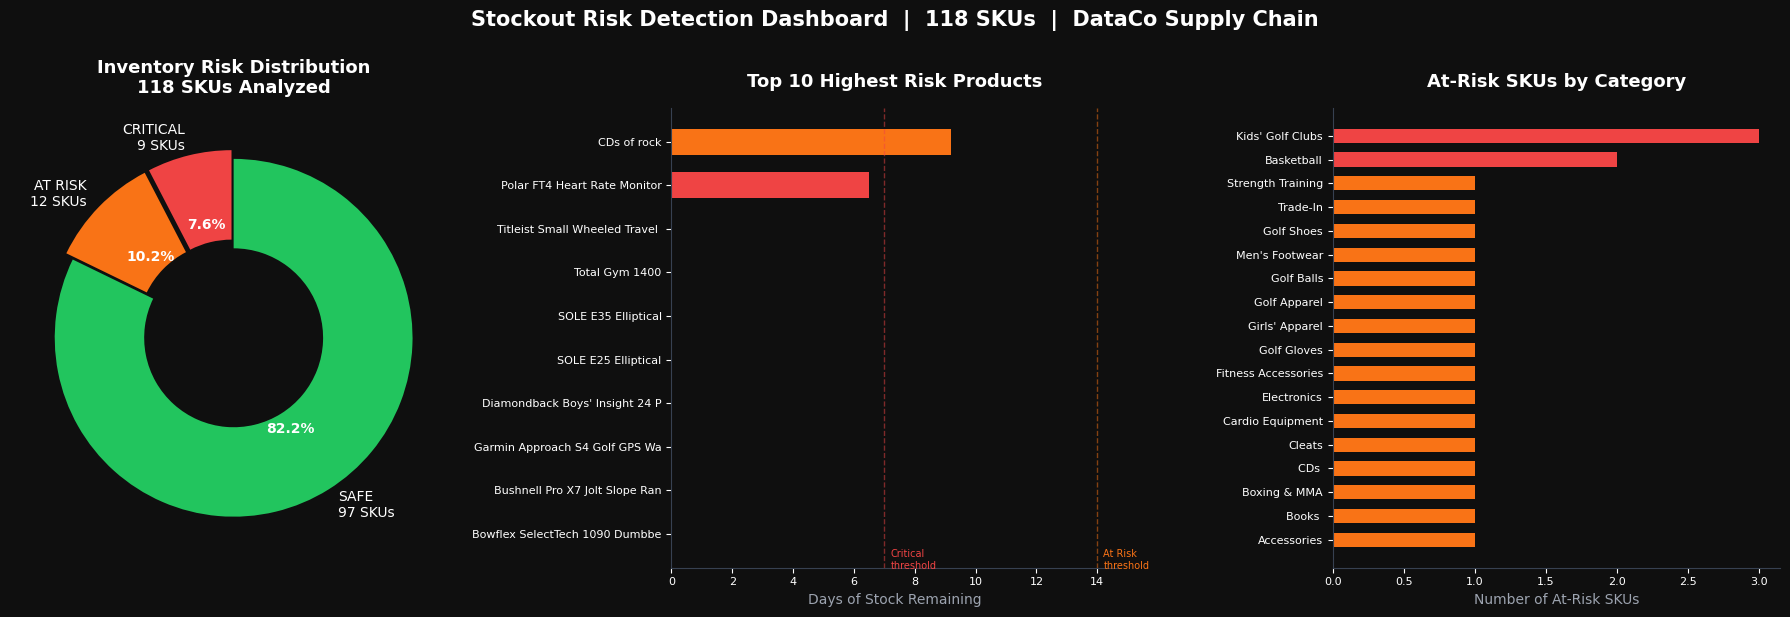

Dashboard saved.

=== FINAL RISK TABLE (Critical & At Risk) ===
                                          Product             Category  Daily Velocity (units)  Current Inventory  Days Remaining Risk Flag
0                                     CDs of rock                 CDs                    0.218                2.0             9.2   AT RISK
1   Nike Men's Deutschland Weltmeister Winners Bl       Girls' Apparel                   0.702                7.0            10.0   AT RISK
2   Bridgestone e6 Straight Distance NFL San Dieg          Electronics                   0.714                8.0            11.2   AT RISK
3                 Glove It Urban Brick Golf Towel             Trade-In                   0.691                8.0            11.6   AT RISK
4   Under Armour Women's Micro G Skulpt Running S         Boxing & MMA                   0.670                8.0            11.9   AT RISK
5         Nike Men's CJ Elite 2 TD Football Cleat       Men's Footwear                  17.626  

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================
# VISUALIZATION 1 — Risk Distribution Donut
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f0f')

# --- Chart 1: Donut chart ---
ax1 = axes[0]
ax1.set_facecolor('#0f0f0f')

sizes = [9, 12, 97]
labels = ['CRITICAL\n9 SKUs', 'AT RISK\n12 SKUs', 'SAFE\n97 SKUs']
colors = ['#ef4444', '#f97316', '#22c55e']
explode = (0.05, 0.05, 0)

wedges, texts, autotexts = ax1.pie(
    sizes, 
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5)
)

for text in texts:
    text.set_color('white')
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax1.set_title('Inventory Risk Distribution\n118 SKUs Analyzed', 
              color='white', fontsize=13, fontweight='bold', pad=15)

# --- Chart 2: Top 10 At-Risk Products ---
ax2 = axes[1]
ax2.set_facecolor('#0f0f0f')

top_risk = velocity_full[velocity_full['risk_flag'].isin(['CRITICAL', 'AT RISK'])]\
    .sort_values('days_remaining').head(10)

# Clean product names for display
top_risk['short_name'] = top_risk['Product Name'].str[:30]

bar_colors = ['#ef4444' if r == 'CRITICAL' else '#f97316' 
              for r in top_risk['risk_flag']]

bars = ax2.barh(top_risk['short_name'], top_risk['days_remaining'], 
                color=bar_colors, edgecolor='none', height=0.6)

ax2.set_facecolor('#0f0f0f')
ax2.tick_params(colors='white', labelsize=8)
ax2.set_xlabel('Days of Stock Remaining', color='#9ca3af', fontsize=10)
ax2.set_title('Top 10 Highest Risk Products', 
              color='white', fontsize=13, fontweight='bold', pad=15)
ax2.spines['bottom'].set_color('#374151')
ax2.spines['left'].set_color('#374151')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.axvline(x=7, color='#ef4444', linestyle='--', alpha=0.5, linewidth=1)
ax2.axvline(x=14, color='#f97316', linestyle='--', alpha=0.5, linewidth=1)
ax2.text(7.2, -0.8, 'Critical\nthreshold', color='#ef4444', fontsize=7)
ax2.text(14.2, -0.8, 'At Risk\nthreshold', color='#f97316', fontsize=7)

# --- Chart 3: Risk by Category (only categories with risk) ---
ax3 = axes[2]
ax3.set_facecolor('#0f0f0f')

cat_with_risk = velocity_full[velocity_full['risk_flag'].isin(['CRITICAL', 'AT RISK'])]\
    .groupby('Category Name')['risk_flag'].count()\
    .sort_values(ascending=True)

bar_colors3 = ['#ef4444' if v >= 2 else '#f97316' for v in cat_with_risk.values]

ax3.barh(cat_with_risk.index, cat_with_risk.values, 
         color=bar_colors3, edgecolor='none', height=0.6)

ax3.set_facecolor('#0f0f0f')
ax3.tick_params(colors='white', labelsize=8)
ax3.set_xlabel('Number of At-Risk SKUs', color='#9ca3af', fontsize=10)
ax3.set_title('At-Risk SKUs by Category', 
              color='white', fontsize=13, fontweight='bold', pad=15)
ax3.spines['bottom'].set_color('#374151')
ax3.spines['left'].set_color('#374151')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- Main title ---
fig.suptitle(
    'Stockout Risk Detection Dashboard  |  118 SKUs  |  DataCo Supply Chain',
    color='white', fontsize=15, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('stockout_risk_dashboard.png', 
            dpi=150, bbox_inches='tight', 
            facecolor='#0f0f0f', edgecolor='none')
plt.show()
print("Dashboard saved.")

# ============================================
# EXPORT — Clean risk table
# ============================================

export = velocity_full[['Product Name', 'Category Name', 'daily_velocity',
                          'simulated_inventory', 'days_remaining', 'risk_flag']]\
    .sort_values(['risk_flag', 'days_remaining'])\
    .reset_index(drop=True)

export.columns = ['Product', 'Category', 'Daily Velocity (units)', 
                   'Current Inventory', 'Days Remaining', 'Risk Flag']

print("\n=== FINAL RISK TABLE (Critical & At Risk) ===")
print(export[export['Risk Flag'].isin(['CRITICAL', 'AT RISK'])].to_string())